# Perturbation Performance vs. Number of Perturbed Genes

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../../scripts')

import numpy as np
import pandas as pd
import decoupler as dc
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.sparse as sp
import scvi
from scipy.stats import pearsonr, spearmanr

import cellina
from cellina import CellinaModel, make_neighbor_perturbation
from cellina._spatial_utils import spatial_neighbors, compute_spatial_features
from perturb_utils import load_crc_slide, _get_domain_labels
from configs.cellina_config import MODEL_ARGS, TRAIN_ARGS, PLAN_KWARGS
from counterfactual_analysis import (
    safe_log2_fold_change, precision_at_k,
    e_distance, subsample_cells, _normalize_counts,
)

plt.rcParams['figure.dpi'] = 100
scvi.settings.seed = 0
print(cellina.__version__)


EDISTANCE_SUBSAMPLE = 500
EDISTANCE_N_ITER = 10


def direction_match(gt_vec, cf_vec, k):
    gt_topk = set(np.argsort(-np.abs(gt_vec))[:k])
    cf_topk = set(np.argsort(-np.abs(cf_vec))[:k])
    intersect = list(gt_topk & cf_topk)
    if len(intersect) == 0:
        return 0.0
    return float(np.mean(np.sign(gt_vec[intersect]) == np.sign(cf_vec[intersect])))


def compute_metrics(ref_expr, pert_expr, obs_expr, top_n=200, eps=1e-8, scale=1e4):
    """Mirrors eval_loo compute_lfc_metrics + get_edistance on raw expression arrays."""
    ref_norm  = _normalize_counts(ref_expr,  eps=eps, scale=scale)
    obs_norm  = _normalize_counts(obs_expr,  eps=eps, scale=scale)
    pert_norm = _normalize_counts(pert_expr, eps=eps, scale=scale)

    mean_ref  = np.nanmean(ref_norm,  axis=0)
    mean_obs  = np.nanmean(obs_norm,  axis=0)
    mean_pert = np.nanmean(pert_norm, axis=0)

    gt_vec = safe_log2_fold_change(mean_obs,  mean_ref, eps=eps)
    cf_vec = safe_log2_fold_change(mean_pert, mean_ref, eps=eps)

    top_features = np.argsort(-np.abs(gt_vec))[:top_n]
    pear,  _ = pearsonr( gt_vec[top_features], cf_vec[top_features])
    spear, _ = spearmanr(gt_vec[top_features], cf_vec[top_features])
    prec     = precision_at_k(gt_vec, cf_vec, k=top_n, use_abs=True)
    dir_m    = direction_match(gt_vec, cf_vec, k=top_n)

    pop_a = np.log1p(obs_norm[:,  top_features])
    pop_b = np.log1p(pert_norm[:, top_features])
    edists = [
        e_distance(subsample_cells(pop_a, EDISTANCE_SUBSAMPLE),
                   subsample_cells(pop_b, EDISTANCE_SUBSAMPLE))
        for _ in range(EDISTANCE_N_ITER)
    ]
    edists_local = [
        e_distance(subsample_cells(pop_a, EDISTANCE_SUBSAMPLE),
                   subsample_cells(pop_b, EDISTANCE_SUBSAMPLE), local=True)
        for _ in range(EDISTANCE_N_ITER)
    ]
    rmse_log1p = float(np.sqrt(np.mean(
        (np.log1p(obs_norm).sum(0) - np.log1p(pert_norm).sum(0)) ** 2
    )))

    return dict(
        pearson_r=float(pear),
        spearman_r=float(spear),
        precision=float(prec),
        direction_match=float(dir_m),
        edistance=float(np.mean(edists)),
        edistance_local=float(np.mean(edists_local)),
        rmse_log1p=rmse_log1p,
    )

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/l

0.7.1


In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
slide_id             = 120
labels_key           = 'coarse_type'
domains_key          = 'typ_clean' # NOTE: this is the same as 'domain' for all slides except 120, where CRC has subtypes
top_n                = 50                        # metric evaluation window (fixed)
top_n_perturb_values = [10, 20, 50, 100, 200, 500, 1000, 2000, 3000] # sweep
batch_size           = 512
min_cells            = 50
base_path        = 'results/perturb_loo'
save_path        = f'{base_path}/trained/crc_{slide_id}_ID'
library_size     = 'latent'

## 1. Data

In [3]:
adata = load_crc_slide(slide_id, labels_key=labels_key, domains_key=domains_key)
print(adata)

ref_label, crc_labels = _get_domain_labels(adata, domains_key)
print(f'ref={ref_label!r}, crc={crc_labels}')

AnnData object with n_obs × n_vars = 707308 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'version', 'dualfiles', 'Run_name', 'Run_Tissue_name', 'ISH.concentration', 'Dash', 'tissue', 'Panel', 'assay_type', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [4]:
spatial_neighbors(adata, bandwidth=100 / 0.12028, max_neighbours=200, standardize=False)
compute_spatial_features(adata)

... storing 'typ_clean' as categorical


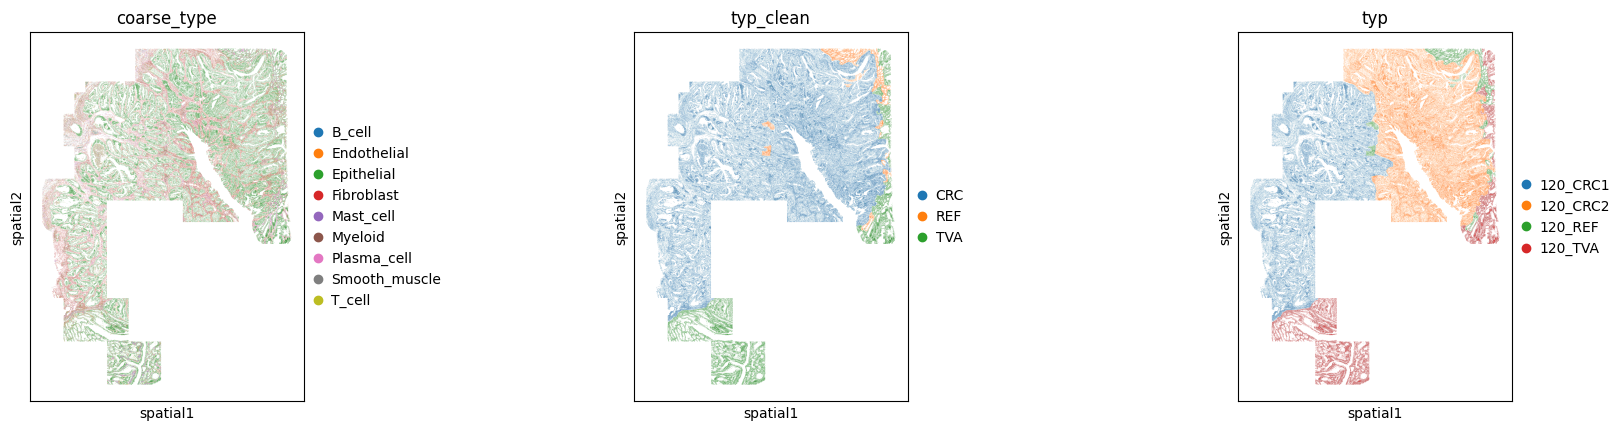

In [5]:
sc.pl.spatial(adata, color=[labels_key, domains_key, 'typ'], spot_size=50)

## 2. Model

In [6]:
CellinaModel.setup_anndata(
    adata,
    batch_key=None,
    labels_key=labels_key,
    domains_key=domains_key,
    layer='counts',
    spatial_obsm_key='spatial_x'
)

model = CellinaModel(adata, **MODEL_ARGS)


INFO     Generating sequential column names                                                                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


In [7]:
train_args = {**TRAIN_ARGS, "devices": [1], "batch_size": batch_size, "train_size": 0.9, "validation_size": 0.1}
model.train(**train_args, plan_kwargs=PLAN_KWARGS)

model.save(save_path, overwrite=True)


INFO: GPU available: True (cuda), used: True
2026-04-21 07:33:47 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-04-21 07:33:47 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-04-21 07:33:47 | [INFO] HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2026-04-21 07:33:47 | [INFO] You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.o

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Monitored metric vae_loss_validation did not improve in the last 10 records. Best score: 819.051. Signaling Trainer to stop.


## 3. Pseudobulk logFC — Global & Cell-type-specific

In [8]:
model = CellinaModel.load(save_path, adata)

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
2026-04-21 09:24:01 | [INFO] Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File results/perturb_loo/trained/crc_120_ID/model.pt already downloaded                                   


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.l

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


In [9]:
adata.obs[domains_key]

c_2_1_982       CRC
c_2_1_1046      CRC
c_2_1_1094      CRC
c_2_1_1095      CRC
c_2_1_1134      CRC
               ... 
c_2_396_1800    CRC
c_2_396_1802    CRC
c_2_396_1806    CRC
c_2_396_1807    CRC
c_2_396_1811    CRC
Name: typ_clean, Length: 707308, dtype: category
Categories (3, object): ['CRC', 'REF', 'TVA']

In [10]:
# Global: all cells pooled together
pdata_global = dc.pp.pseudobulk(
    adata=adata, sample_col=domains_key, groups_col=None, mode='sum', layer='counts'
)
sc.pp.normalize_total(pdata_global, target_sum=1e4)
sc.pp.log1p(pdata_global)

_crc_X    = pdata_global[pdata_global.obs[domains_key].isin(crc_labels)].X
_ref_X    = pdata_global[pdata_global.obs[domains_key] == ref_label].X
_crc_mean = np.asarray(_crc_X.mean(axis=0)).flatten() if sp.issparse(_crc_X) else _crc_X.mean(axis=0).flatten()
_ref_mean = np.asarray(_ref_X.mean(axis=0)).flatten() if sp.issparse(_ref_X) else _ref_X.mean(axis=0).flatten()
global_logfc_series = pd.Series(_crc_mean - _ref_mean, index=pdata_global.var_names)

# Cell-type-specific
pdata_ct = dc.pp.pseudobulk(
    adata=adata, sample_col=domains_key, groups_col=labels_key, mode='sum', layer='counts'
)
sc.pp.normalize_total(pdata_ct, target_sum=1e4)
sc.pp.log1p(pdata_ct)

cell_types_with_both = [
    ct for ct in pdata_ct.obs[labels_key].unique()
    if ((pdata_ct.obs[domains_key] == ref_label) & (pdata_ct.obs[labels_key] == ct)).any()
    and (pdata_ct.obs[domains_key].isin(crc_labels) & (pdata_ct.obs[labels_key] == ct)).any()
]

_ct_rows = []
for _ct in cell_types_with_both:
    _crc_ct = pdata_ct[pdata_ct.obs[domains_key].isin(crc_labels) & (pdata_ct.obs[labels_key] == _ct)].X
    _ref_ct = pdata_ct[(pdata_ct.obs[domains_key] == ref_label)   & (pdata_ct.obs[labels_key] == _ct)].X
    _crc_m  = np.asarray(_crc_ct.mean(axis=0)).flatten() if sp.issparse(_crc_ct) else _crc_ct.mean(axis=0).flatten()
    _ref_m  = np.asarray(_ref_ct.mean(axis=0)).flatten() if sp.issparse(_ref_ct) else _ref_ct.mean(axis=0).flatten()
    _ct_rows.append(pd.Series(_crc_m - _ref_m, index=pdata_ct.var_names, name=_ct))
domain_logfc_df = pd.concat(_ct_rows, axis=1).T

print(f"Global logFC: {global_logfc_series.shape[0]} genes")
print(f"CT-specific logFC: {domain_logfc_df.shape} (cell types × genes)")

Global logFC: 3000 genes
CT-specific logFC: (9, 3000) (cell types × genes)


## 4. Pre-compute Fixed Expressions per Cell Type

In [11]:
import scanpy as sc  # needed for sc.pp calls above in case not imported

ref_idxs = {}   # ct → indices in REF
crc_idxs = {}   # ct → indices in CRC
ref_exprs = {}  # ct → (n_ref, n_genes)
cf_exprs  = {}  # ct → (n_crc, n_genes)  real CRC, ground truth
swap_exprs = {} # ct → (n_ref, n_genes)  counterfactual (graph swap)

cell_types = []
for ct in sorted(cell_types_with_both):
    ref_idx = np.where(
        (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == ref_label)
    )[0]
    crc_idx = np.where(
        (adata.obs[labels_key] == ct) & (adata.obs[domains_key].isin(crc_labels))
    )[0]
    if len(ref_idx) < min_cells or len(crc_idx) < min_cells:
        print(f"  skip {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")
        continue
    print(f"  {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")
    ref_idxs[ct]  = ref_idx
    crc_idxs[ct]  = crc_idx
    ref_exprs[ct]  = model.get_normalized_expression(indices=ref_idx, batch_size=batch_size, library_size=library_size)
    cf_exprs[ct]   = model.get_normalized_expression(indices=crc_idx, batch_size=batch_size, library_size=library_size)
    swap_exprs[ct] = model.get_counterfactual_expression(ref_idx, crc_idx, batch_size=batch_size, library_size=library_size)
    cell_types.append(ct)

print(f"\nEvaluating {len(cell_types)} cell types: {cell_types}")

  B_cell: ref=619, crc=2093
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  Endothelial: ref=522, crc=18009


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  Epithelial: ref=10853, crc=320748


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  Fibroblast: ref=3311, crc=115562


...

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  T_cell: ref=2466, crc=34279


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        

Evaluating 8 cell types: ['B_cell', 'Endothelial', 'Epithelial', 'Fibroblast', 'Myeloid', 'Plasma_cell', 'Smooth_muscle', 'T_cell']


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


## 5. Counterfactual Baseline (Fixed)

In [12]:
_metric_keys = ('pearson_r', 'spearman_r', 'precision', 'direction_match',
                'edistance', 'edistance_local', 'rmse_log1p')

raw = {k: [] for k in _metric_keys}
for ct in cell_types:
    stats = compute_metrics(ref_exprs[ct], swap_exprs[ct], cf_exprs[ct], top_n=top_n)
    for k in _metric_keys:
        raw[k].append(stats[k])

cf_avg = {k: float(np.mean(raw[k])) for k in _metric_keys}
for k, v in cf_avg.items():
    print(f"Counterfactual avg {k:20s} = {v:.4f}")

cf_ct_spearman  = {ct: raw['spearman_r'][i] for i, ct in enumerate(cell_types)}
cf_ct_precision = {ct: raw['precision'][i]  for i, ct in enumerate(cell_types)}


Counterfactual avg pearson_r            = 0.9641
Counterfactual avg spearman_r           = 0.8767
Counterfactual avg precision            = 0.7025
Counterfactual avg direction_match      = 1.0000
Counterfactual avg edistance            = 0.5085
Counterfactual avg edistance_local      = 0.3928
Counterfactual avg rmse_log1p           = 81037.0497


## 6. Sweep: Global vs Cell-type-specific

In [13]:
global_rows = []
ctspec_rows = []

for n in top_n_perturb_values:
    print(f"\n── top_n_perturb = {n} ──")

    # ── Global perturbation ──────────────────────────────────────────────────
    top_genes = global_logfc_series.abs().nlargest(n).index.tolist()
    make_neighbor_perturbation(
        adata,
        perturbations={g: float(global_logfc_series[g]) for g in top_genes},
        obsm_key_out='spatial_x_cf', base=np.e,
    )
    g_vals = {k: [] for k in _metric_keys}
    for ct in cell_types:
        pert_expr = model.get_perturbed_expression(
            adata=adata, indices=ref_idxs[ct], spatial_obsm_key='spatial_x_cf',
            batch_size=batch_size, library_size=library_size,
        )
        for k, v in compute_metrics(ref_exprs[ct], pert_expr, cf_exprs[ct], top_n=top_n).items():
            g_vals[k].append(v)
    g_avg = {k: float(np.mean(g_vals[k])) for k in _metric_keys}
    global_rows.append({
        'top_n_perturb': n,
        **{f'global_{k}': g_avg[k] for k in _metric_keys},
        **{f'global_ct_spearman_{ct}': g_vals['spearman_r'][i] for i, ct in enumerate(cell_types)},
        **{f'global_ct_precision_{ct}': g_vals['precision'][i]  for i, ct in enumerate(cell_types)},
    })
    print("  global:    ", {k: f"{g_avg[k]:.3f}" for k in _metric_keys})

    # ── Cell-type-specific perturbation ──────────────────────────────────────
    logfc_series_dict = {}
    for ct in domain_logfc_df.index:
        s = domain_logfc_df.loc[ct]
        logfc_series_dict[ct] = s[s.abs().nlargest(n).index]
    make_neighbor_perturbation(
        adata, perturbations=logfc_series_dict, groupby=labels_key,
        obsm_key_out='spatial_x_cf', base=np.e,
    )
    c_vals = {k: [] for k in _metric_keys}
    for ct in cell_types:
        pert_expr = model.get_perturbed_expression(
            adata=adata, indices=ref_idxs[ct], spatial_obsm_key='spatial_x_cf',
            batch_size=batch_size, library_size=library_size,
        )
        for k, v in compute_metrics(ref_exprs[ct], pert_expr, cf_exprs[ct], top_n=top_n).items():
            c_vals[k].append(v)
    c_avg = {k: float(np.mean(c_vals[k])) for k in _metric_keys}
    ctspec_rows.append({
        'top_n_perturb': n,
        **{f'ctspec_{k}': c_avg[k] for k in _metric_keys},
        **{f'ctspec_ct_spearman_{ct}': c_vals['spearman_r'][i] for i, ct in enumerate(cell_types)},
        **{f'ctspec_ct_precision_{ct}': c_vals['precision'][i]  for i, ct in enumerate(cell_types)},
    })
    print("  CT-spec:   ", {k: f"{c_avg[k]:.3f}" for k in _metric_keys})

if 'spatial_x_cf' in adata.obsm:
    del adata.obsm['spatial_x_cf']

sweep_df = pd.DataFrame(global_rows).merge(pd.DataFrame(ctspec_rows), on='top_n_perturb')
top_n_perturb_values = sweep_df['top_n_perturb'].tolist()



── top_n_perturb = 10 ──
  global:     {'pearson_r': '0.780', 'spearman_r': '0.685', 'precision': '0.380', 'direction_match': '0.986', 'edistance': '3.441', 'edistance_local': '2.136', 'rmse_log1p': '81043.524'}
  CT-spec:    {'pearson_r': '0.816', 'spearman_r': '0.746', 'precision': '0.430', 'direction_match': '0.988', 'edistance': '3.558', 'edistance_local': '2.153', 'rmse_log1p': '81045.718'}

── top_n_perturb = 20 ──
  global:     {'pearson_r': '0.806', 'spearman_r': '0.708', 'precision': '0.398', 'direction_match': '0.994', 'edistance': '3.345', 'edistance_local': '2.054', 'rmse_log1p': '81040.533'}
  CT-spec:    {'pearson_r': '0.848', 'spearman_r': '0.769', 'precision': '0.455', 'direction_match': '1.000', 'edistance': '3.224', 'edistance_local': '1.977', 'rmse_log1p': '81043.308'}

── top_n_perturb = 50 ──
  global:     {'pearson_r': '0.832', 'spearman_r': '0.750', 'precision': '0.432', 'direction_match': '0.993', 'edistance': '2.860', 'edistance_local': '1.787', 'rmse_log1p': 

In [14]:
import os

results_dir = f'{base_path}/gene_range'
os.makedirs(results_dir, exist_ok=True)

sweep_df.to_csv(f'{results_dir}/sweep_results.csv', index=False)
pd.DataFrame([cf_avg]).to_csv(f'{results_dir}/baseline_metrics.csv', index=False)
pd.Series(cf_ct_spearman,  name='spearman_r').to_csv(f'{results_dir}/cf_ct_spearman.csv')
pd.Series(cf_ct_precision, name='precision').to_csv(f'{results_dir}/cf_ct_precision.csv')

print(f"Saved to {results_dir}/")


Saved to results/perturb_loo/gene_range/


In [15]:
# ── Load results (run this cell to skip the sweep and go straight to plotting) ──
results_dir = f'{base_path}/gene_range'
top_n = 50  # fallback if cell-2 was not run

sweep_df    = pd.read_csv(f'{results_dir}/sweep_results.csv')
baseline_df = pd.read_csv(f'{results_dir}/baseline_metrics.csv')
cf_avg      = baseline_df.iloc[0].to_dict()
top_n_perturb_values = sweep_df['top_n_perturb'].tolist()

cf_ct_spearman  = pd.read_csv(f'{results_dir}/cf_ct_spearman.csv',  index_col=0)['spearman_r']
cf_ct_precision = pd.read_csv(f'{results_dir}/cf_ct_precision.csv', index_col=0)['precision']

print(f"Loaded from {results_dir}/")


Loaded from results/perturb_loo/gene_range/


## 7. Summary Plot

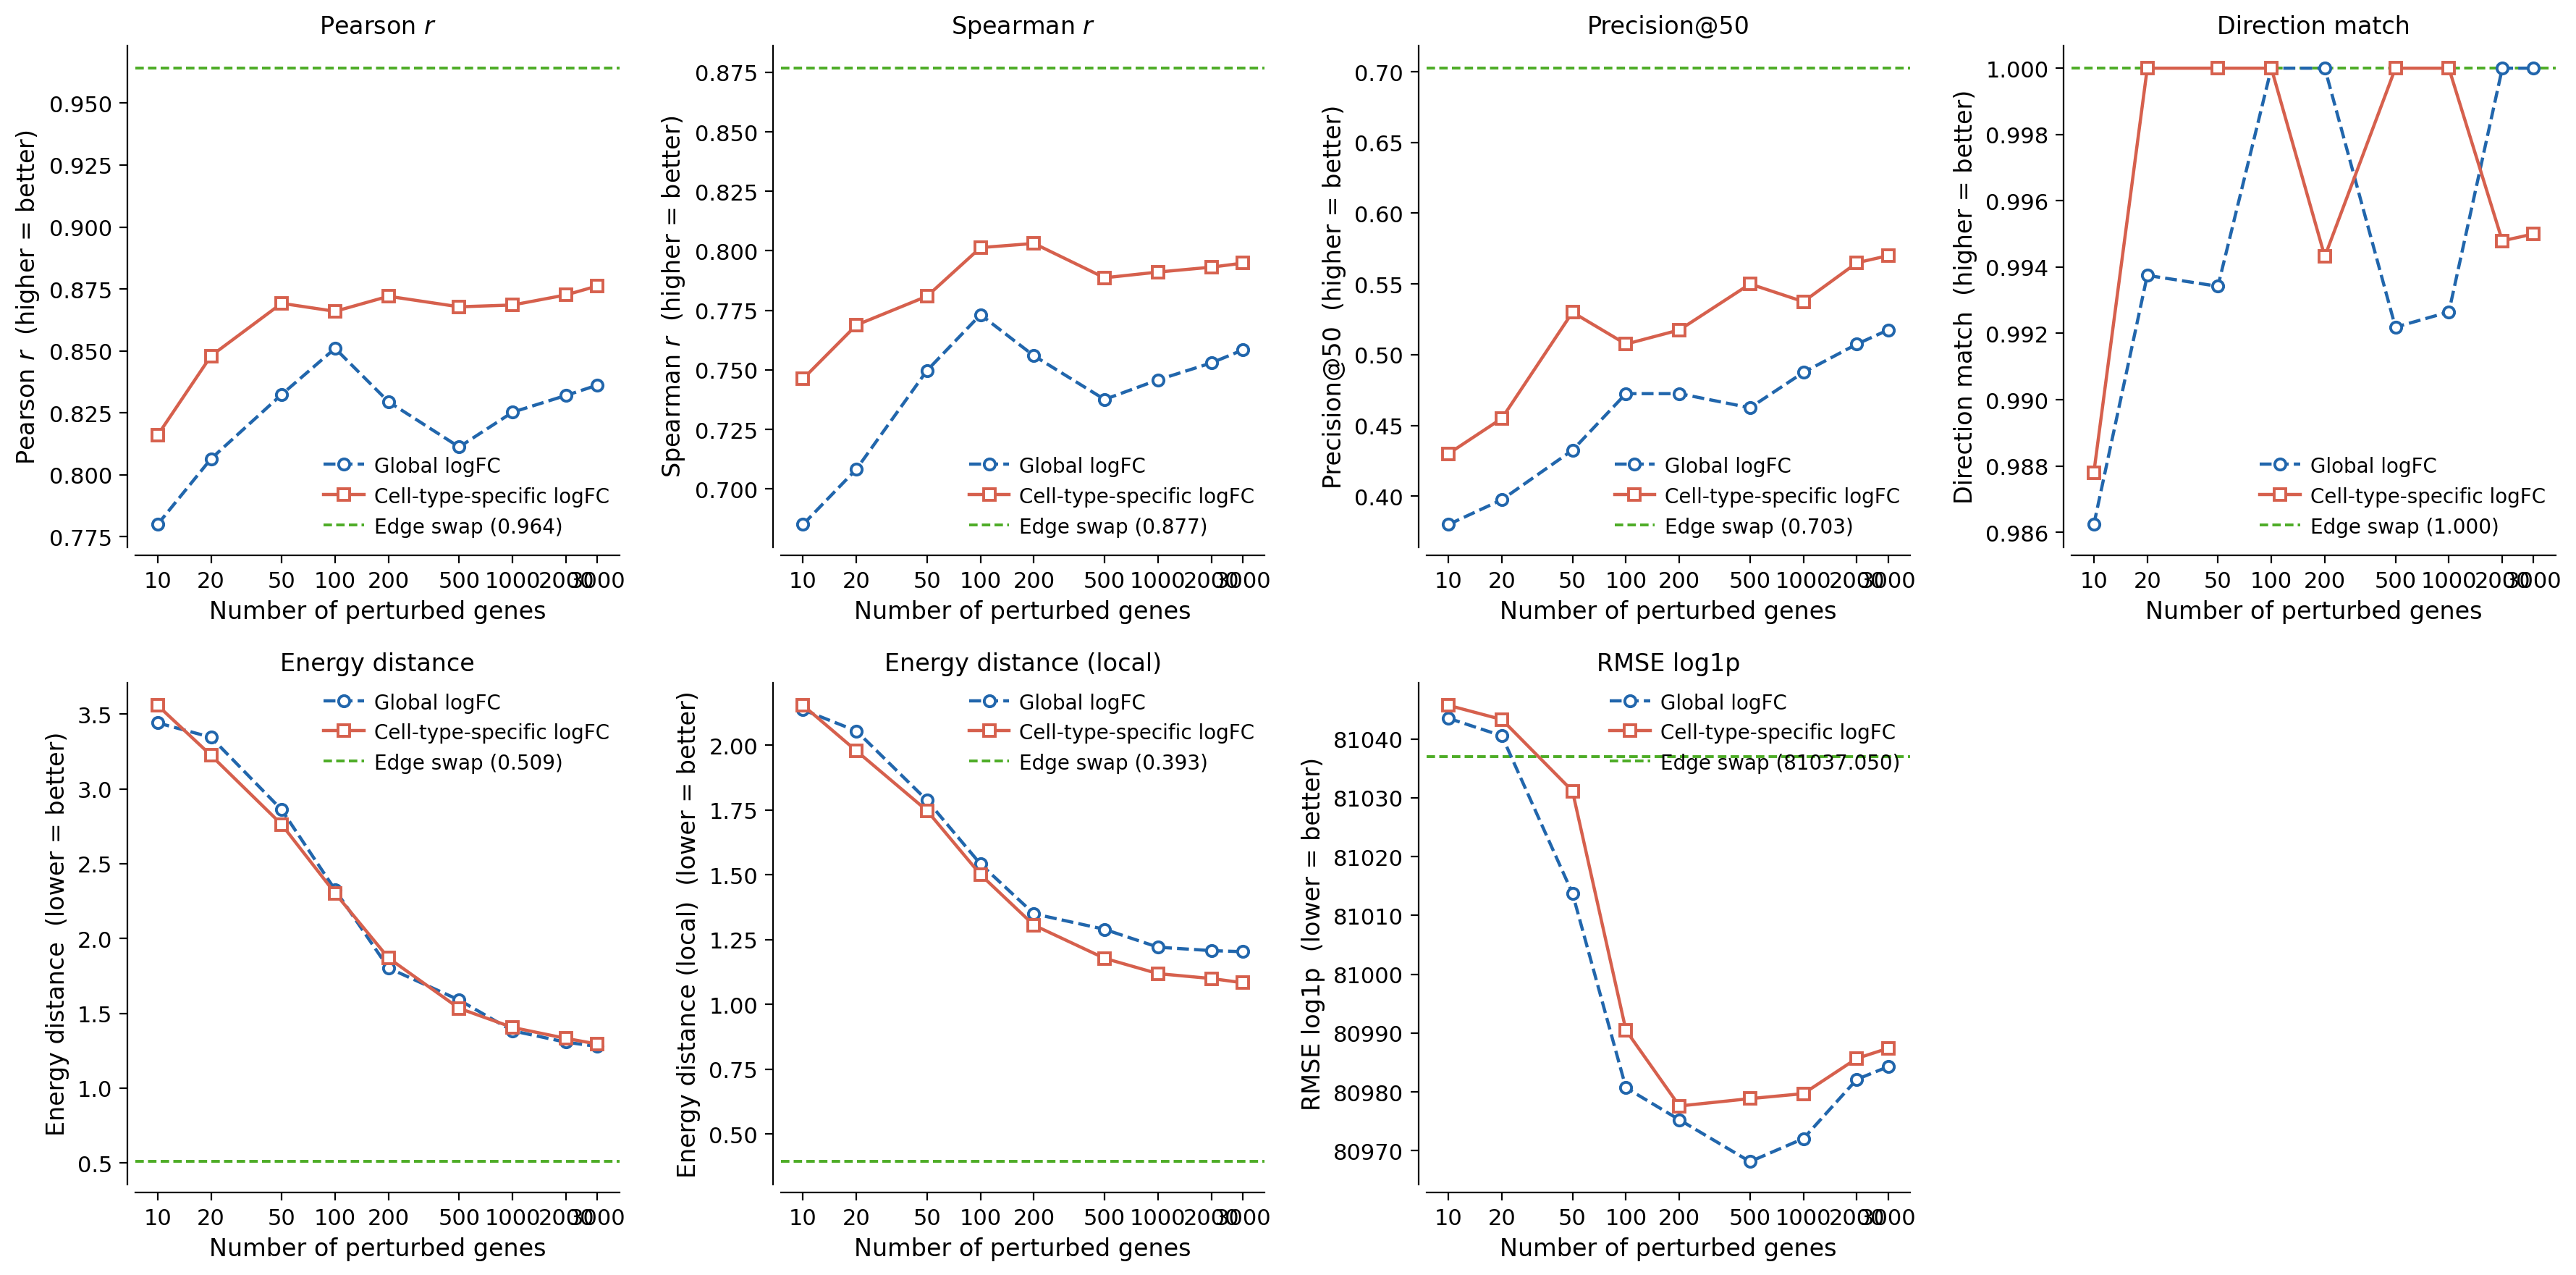

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    'figure.dpi': 200,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 13,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 13,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

BLUE   = '#2166AC'
ORANGE = '#D6604D'
GREEN  = '#4DAC26'

metrics = [
    ('pearson_r',       'Pearson $r$',              True),
    ('spearman_r',      'Spearman $r$',              True),
    ('precision',       f'Precision@{top_n}',        True),
    ('direction_match', 'Direction match',            True),
    ('edistance',       'Energy distance',            False),
    ('edistance_local', 'Energy distance (local)',    False),
    ('rmse_log1p',      'RMSE log1p',                 False),
]

ncols = 4
nrows = -(-len(metrics) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4.5))
axes = axes.flatten()

for i, (key, ylabel, higher_better) in enumerate(metrics):
    ax = axes[i]
    direction = 'higher = better' if higher_better else 'lower = better'
    cf_val = cf_avg[key]

    ax.plot(
        top_n_perturb_values, sweep_df[f'global_{key}'],
        color=BLUE, ls='--', marker='o', ms=5.5, lw=1.6,
        markerfacecolor='white', markeredgewidth=1.4,
        label='Global logFC', zorder=3,
    )
    ax.plot(
        top_n_perturb_values, sweep_df[f'ctspec_{key}'],
        color=ORANGE, ls='-', marker='s', ms=5.5, lw=1.6,
        markerfacecolor='white', markeredgewidth=1.4,
        label='Cell-type-specific logFC', zorder=3,
    )
    ax.axhline(
        cf_val, color=GREEN, ls=(0, (3, 1.5)), lw=1.4,
        label=f'Edge swap ({cf_val:.3f})', zorder=2,
    )
    ax.set_xscale('log')
    ax.set_xticks(top_n_perturb_values)
    ax.set_xticklabels([str(v) for v in top_n_perturb_values], rotation=45, ha='right')
    ax.xaxis.set_minor_locator(ticker.NullLocator())
    ax.set_xlabel('Number of perturbed genes', fontsize=12)
    ax.set_ylabel(f'{ylabel}  ({direction})')
    ax.set_title(ylabel)
    ax.spines['left'].set_position(('outward', 4))
    ax.spines['bottom'].set_position(('outward', 4))
    ax.legend(frameon=False, handlelength=2.0, fontsize=10)

for j in range(len(metrics), len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.show()
